In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import pickle
import matplotlib.pyplot as plt
from ensemble_rbm import load_ensemble_results

In [86]:
def flatten_rbm(W, bv, bh):
    return jnp.concatenate([
        W.reshape(-1),
        bv.reshape(-1),
        bh.reshape(-1)])

directory = '/home/shailesh/Projects/Local/BoltzmannMachine/Claude/tiny_ising_3x3_statistics/run2'
ens_results = load_ensemble_results(directory)
sectors = ens_results.keys()

In [97]:
L = 3
N = L * L

bit_positions = jnp.arange(N).reshape(L, L)
transposed_positions = bit_positions.T.flatten()

P = jnp.zeros((N, N))
P = P.at[transposed_positions, jnp.arange(N)].set(1)
perm = jnp.argmax(P, axis=1)
# configs
numbers = jnp.arange(2**N, dtype=jnp.int32)
bits = ((numbers[:, None] >> jnp.arange(N)) & 1)
bits = bits.astype(jnp.float32)
bits = 2 * bits - 1


def rbm_free_energy(v, W, bv, bh):
    hidden_arg = v @ W + bh
    hidden_term = jnp.sum(jnp.log1p(jnp.exp(hidden_arg)))
    return -v @ bv - hidden_term


def build_feature_vector(W, bv, bh, configs):
    return jax.vmap(lambda v: rbm_free_energy(v, W, bv, bh))(configs)


def apply_visible_symmetry_configs(configs, P):
    perm = jnp.argmax(P, axis=1)
    return configs[:,  perm]


X = []
Xd = []

for sector, ens in ens_results.items():
    
    for instance in ens:
        W, bv, bh = instance['W'], instance['bv'], instance['bh']

    # original RBM function on config space
    X.append(build_feature_vector(W, bv, bh, bits))

    # symmetry-transformed configs
    bits_d = apply_visible_symmetry_configs(bits, P)

    # RBM evaluated on transformed configs
    Xd.append(build_feature_vector(W, bv, bh, bits_d))


X = jnp.stack(X)
Xd = jnp.stack(Xd)

In [62]:
L = 3
bit_positions = jnp.arange(L*L).reshape(L, L)
transposed_positions = bit_positions.T.flatten()

N = L * L
P = jnp.zeros((N, N))
P = P.at[transposed_positions, jnp.arange(N)].set(1)

def flatten_rbm(W, bv, bh):
    return jnp.concatenate([
        W.reshape(-1),
        bv.reshape(-1),
        bh.reshape(-1)])

def apply_visible_symmetry(W, bv, bh, P):
    W_new = P.T @ W
    bv_new = P.T @ bv
    bh_new = bh
    return W_new, bv_new, bh_new

hamiltonian_data = {}
X = []
Xd = []
for sector, ens in ens_results.items():
    hamiltonian_data[sector] = []
    W,bv,bh = (instance['W'],instance['bv'],instance['bh'])
    X.append(flatten_rbm(W,bv,bh))
    W,b,h = apply_visible_symmetry(W, bv, bh, P)
    Xd.append(flatten_rbm(W,b,h))
X = jnp.array(X)   # shape (4, D)
Xd = jnp.array(Xd)

In [98]:
X.shape, Xd.shape

((4, 512), (4, 512))

In [93]:
hamiltonian_data = {}
X = []
Xd = []
for sector, ens in ens_results.items():
    hamiltonian_data[sector] = []
    W,bv,bh = (instance['W'],instance['bv'],instance['bh'])
    X.append(flatten_rbm(W,bv,bh))
    W,b,h = apply_visible_symmetry(W, bv, bh, P)
    Xd.append(flatten_rbm(W,b,h))
X = jnp.array(X)   # shape (4, D)
Xd = jnp.array(Xd)
X.shape

(4, 99)

In [100]:
# Projection from Ising microstates onto 4 sectors
zFLattice = jnp.array([[1,  0, -1,  0],  # ap
                       [0,  1,  1,  0],  # aa
                       [1, -1,  0,  0]])  
fermions = jnp.sqrt((zFLattice @ X).astype(complex))
dfermions = jnp.sqrt((zFLattice @ X).astype(complex))

In [76]:
# Projection from Ising microstates onto 4 sectors
zFLattice = jnp.array([[1,  0, -1,  0],  # ap
                       [0,  1,  1,  0],  # aa
                       [1, -1,  0,  0]])  
fermions = jnp.sqrt((zFLattice @ X).astype(complex))
dfermions = ((fermions.reshape(-1, L, L)).transpose(0,2,1)).reshape(-1,L**2)

In [72]:
def overlap(w1,w2):
    ''' overlap matrix of three wave functions with another three wave functions '''
    return jnp.conj(w2) @ w1.T

In [101]:
wp,dw = fermions,dfermions
dw_dot_wp = overlap(wp,dw)
dw_dot_wp

Array([[ 912.27075   +0.j     , 1211.7744 +1427.5613j ,
         867.8998   +82.75347j],
       [1211.7744 -1427.5613j , 9182.212     +0.j     ,
        2369.072  -2572.099j  ],
       [ 867.8999   -82.75346j, 2369.072  +2572.099j  ,
        3075.4492    +0.j     ]], dtype=complex64)

In [82]:
jnp.round(jnp.abs(wp),1)

Array([[0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [1., 1., 1., 1., 1., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [75]:
norms

Array([0.       +0.j, 2.2585354+0.j, 0.       +0.j], dtype=complex64)

In [104]:
norms = jnp.sqrt(jnp.diag(dw_dot_wp))
wp = wp/norms[:,None]
dw = dw/norms[:,None]
dw_dot_wp = overlap(wp,dw)
dr, dphi = jnp.abs(dw_dot_wp), jnp.angle(dw_dot_wp)

In [105]:
dr, dphi

(Array([[1.0000002 , 0.6469798 , 0.52049774],
        [0.6469798 , 1.        , 0.6580414 ],
        [0.5204976 , 0.6580414 , 1.0000001 ]], dtype=float32),
 Array([[ 0.        ,  0.8669747 ,  0.09506162],
        [-0.8669747 ,  0.        , -0.826464  ],
        [-0.09506162,  0.826464  ,  0.        ]], dtype=float32))

In [107]:
jnp.round(dw_dot_wp,2)

Array([[1.  +0.j        , 0.42+0.48999998j, 0.52+0.05j      ],
       [0.42-0.48999998j, 1.  +0.j        , 0.45-0.48j      ],
       [0.52-0.05j      , 0.45+0.48j      , 1.  +0.j        ]],      dtype=complex64)

In [108]:
#diagonalizing the overlap matrix to extract the orthonormal basis
eigen, basis_change = jnp.linalg.eigh(dw_dot_wp)

In [109]:
eigen, basis_change

(Array([0.29934153, 0.48180968, 2.2188497 ], dtype=float32),
 Array([[-0.4065996 +0.j        , -0.7204111 +0.j        ,
         -0.5618582 +0.j        ],
        [ 0.60579264-0.51103204j, -0.043248  -0.07543273j,
         -0.3829412 +0.4665376j ],
        [-0.4377848 -0.12199645j,  0.6871007 +0.03660738j,
         -0.5641848 +0.04134734j]], dtype=complex64))

In [25]:
psi = jnp.sqrt(fermions.astype(complex))
dpsi = jnp.sqrt(dfermions.astype(complex))

jnp.conj(dpsi) @ psi.T

Array([[70.606445 -1.5116572j , 41.205124 -6.444068j  ,
        27.845177 +4.518895j  , 20.953783 +9.728288j  ],
       [39.90714  +1.791985j  , 67.00711  -3.1868987j ,
        49.274185 +4.002691j  , 16.225096+21.12732j   ],
       [25.278723-10.573084j  , 47.18489 -12.683923j  ,
        73.91313  -5.2870674j , 39.648857 -0.19755602j],
       [20.198633 -9.445163j  , 16.252304-22.019077j  ,
        37.94803  -1.7205219j , 53.264717 +1.4712691j ]], dtype=complex64)

In [36]:
bits.shape

(512, 9)

In [37]:
transposed_positions

Array([0, 3, 6, 1, 4, 7, 2, 5, 8], dtype=int32)

In [35]:
L = 3
numbers = jnp.arange(2**(L*L), dtype=jnp.uint16)
# bits shape: (65536, 16)
bits = ((numbers[:, None] >> (jnp.arange(L*L))) & 1)

# 2. Define the transpose permutation for the 16 bit positions
# Reshape a dummy index array to 4x4, transpose it, and flatten it
bit_positions = jnp.arange(L*L).reshape(L, L)
transposed_positions = bit_positions.T.flatten()

# 3. Rearrange the bits according to the transpose
# This puts the bit that was at (row, col) into (col, row)
transposed_bits = bits[:, transposed_positions]

In [31]:
jnp.outer(transposed_positions,transposed_positions)

Array([[ 0,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  9, 18,  3, 12, 21,  6, 15, 24],
       [ 0, 18, 36,  6, 24, 42, 12, 30, 48],
       [ 0,  3,  6,  1,  4,  7,  2,  5,  8],
       [ 0, 12, 24,  4, 16, 28,  8, 20, 32],
       [ 0, 21, 42,  7, 28, 49, 14, 35, 56],
       [ 0,  6, 12,  2,  8, 14,  4, 10, 16],
       [ 0, 15, 30,  5, 20, 35, 10, 25, 40],
       [ 0, 24, 48,  8, 32, 56, 16, 40, 64]], dtype=int32)

In [ ]:
#transposed_positions = bit_positions.T.flatten()

# 3. Rearrange the bits according to the transpose
# This puts the bit that was at (row, col) into (col, row)
#transposed_bits = bits[:, transposed_positions]

In [11]:
Xc = X - jnp.mean(X, axis=0, keepdims=True)
C = Xc @ Xc.T

eigvals, U = jnp.linalg.eigh(C)
idx = jnp.argsort(eigvals)[::-1]
U = U[:, idx]

rbm_swapped = [PP, PA, AP, AA]

In [ ]:
def build_X(rbm_param):
    X = []
    for W, bv, bh in rbm_param:
        X.append(flatten_rbm(W, bv, bh))
    return jnp.stack(X)

X_t = build_X(rbm_param)

rbm_dual = [
    rbm_param[0],
    rbm_param[2],
    rbm_param[1],
    rbm_param[3]
]

X_s = build_X(rbm_dual)

In [3]:
# Extract Fermion Wave Functions
                    
def psimajorana(weights, drop_RR=True):

    # ------------------------------------------------------------------
    # reduced GSO projection after excluding RR sector and using RR=0
    # to simplify the partition function identities
    # ------------------------------------------------------------------
    zFp = jnp.array([[0,  1,  1,0],  # NS, NS
                    [1,  0, -1,0],  # NS, R
                    [1, -1,  0,0]], dtype=jnp.float64)  # R, NS
    if drop_RR:
        weights = weights[:-1]
    psiF = zFp @ spinStateWts
    return psiF

def wmajorana(spinweights, drop_RR=True):
    psi = psimajorana(spinweights,drop_RR)
    return jnp.sqrt(psi.astype(complex))

def s_transform(spinStwts,L):
    dualSpins = jnp.reshape(spinStateWts,(-1,L,L))
    dualSpins = jnp.transpose(dualSpins,axes=(0,2,1))
    dualSpins = jnp.array([conf.reshape(-1) for conf in dualSpins])
    return dualSpins

def overlap(w1,w2):
    ''' overlap matrix of three wave functions with another three wave functions '''
    return jnp.conj(w2) @ w1.T

# make orthonormal copies
def orthogonalizeParam(w1,w2):
    ''' take 3 vectors w1 and 3 vectors w2 with overlap neq Id(3x3) and obtain 
    the combinations which are mutually orthonormal '''
    ovlapMatrix = overlap(w1,w2)
    norms, transform = jnp.linalg.eigh(ovlapMatrix)
    return norms, transform

def orthonormalize(w1,w2):
    norms, transform = orthogonalizeParam(w1,w2) 
    orthotrsf= lambda w: transform.T @ w/jnp.sqrt(norms[:,None])
    return orthotrsf(w1), orthotrsf(w2)

(4, 66048)

In [35]:
np.mean(np.abs(W)),np.mean(np.abs(bv)),np.mean(bh)

(np.float32(0.056479648), np.float32(0.19217369), np.float32(0.8783869))

In [58]:
import numpy as np

def marginalized_energy(v, W, b, c):
    """
    Computes the marginalized energy E(v) for a batch of visible vectors.
    Note: Under your convention, P(v) propto exp(E(v)).
    v: array of shape (batch_size, n_v)
    W: array of shape (n_v, n_h)
    b: array of shape (n_h,)
    c: array of shape (n_v,)
    """
    # Linear visible term: \sum c_k v_k
    linear_term = np.dot(v, c) 
    
    # Hidden layer activation term: \sum \log(1 + exp(vW + b))
    # Using log(1 + exp(x)) = softplus(x)
    activation = np.dot(v, W) + b
    
    # Stable softplus implementation to prevent overflow
    softplus = np.log(1+np.exp(activation)) # np.log1p(np.exp(-np.abs(activation))) + np.maximum(activation, 0)
    hidden_term = np.sum(softplus, axis=1)
    
    return linear_term + hidden_term

def intermediate_energy(v, params_ap, params_pa, beta, target="mix_over_ap"):
    """
    Computes the energy for the interpolating distribution at a given beta.
    """
    W_ap, b_ap, c_ap = params_ap
    W_pa, b_pa, c_pa = params_pa
    
    E_ap = marginalized_energy(v, W_ap, b_ap, c_ap)
    E_pa = marginalized_energy(v, W_pa, b_pa, c_pa)
    
    if target == "mix_over_ap":
        # Paths from 2*E_ap (beta=0) to (E_ap + E_pa) (beta=1)
        return (2.0 - beta) * E_ap + beta * E_pa
    elif target == "mix_over_pa":
        # Paths from 2*E_pa (beta=0) to (E_ap + E_pa) (beta=1)
        return (2.0 - beta) * E_pa + beta * E_ap

def metropolis_hastings_step(v, E_current, params_ap, params_pa, beta, target):
    """
    Performs one Metropolis-Hastings sweep over the visible units.
    """
    n_samples, n_v = v.shape
    v_next = np.copy(v)
    
    # Propose flips for visible units (flipping bits for binary variables {0, 1})
    # You can flip one random bit per sample for a standard MH step
    flip_indices = np.random.randint(0, n_v, size=n_samples)
    v_next[np.arange(n_samples), flip_indices] = 1 - v_next[np.arange(n_samples), flip_indices]
    
    E_prop = intermediate_energy(v_next, params_ap, params_pa, beta, target)
    
    # Acceptance probability under convention P(v) \propto exp(E(v))
    # Prob = min(1, exp(E_prop - E_current))
    log_acceptance_ratio = E_prop - E_current
    acceptance_prob = np.exp(np.minimum(0.0, log_acceptance_ratio))
    
    accept = np.random.rand(n_samples) < acceptance_prob
    
    v[accept] = v_next[accept]
    E_current[accept] = E_prop[accept]

    # Insert inside metropolis_hastings_step to monitor mixing
    # If this rate is near 0%, your chain is frozen and AIS will fail.
    
    return v, E_current

def sample_base_rbm(params, n_samples, steps=100):
    """
    Samples from the base distribution P(v) propto exp(2 * E_base(v)) using Gibbs sampling.
    Note the factor of 2, meaning effective parameters are 2*W, 2*b, 2*c.
    """
    W, b, c = params
    n_v, n_h = W.shape
    
    # Initialize random visible states
    v = np.random.randint(0, 2, size=(n_samples, n_v)).astype(np.float64)
    
    for _ in range(steps):
        # Hidden given Visible (with factor of 2)
        p_h = 1.0 / (1.0 + np.exp(-(2.0 * np.dot(v, W) + 2.0 * b)))
        h = (np.random.rand(n_samples, n_h) < p_h).astype(np.float64)
        
        # Visible given Hidden (with factor of 2)
        p_v = 1.0 / (1.0 + np.exp(-(2.0 * np.dot(h, W.T) + 2.0 * c)))
        v = (np.random.rand(n_samples, n_v) < p_v).astype(np.float64)
        
    return v

def get_sigmoidal_betas(n_steps, temperature=1.0):
    """
    Generates a beta schedule clustered around 0.5.
    Lower temperature = sharper clustering around 0.5.
    """
    # Create a linear space centered at 0
    x = np.linspace(-3.0 * temperature, 3.0 * temperature, n_steps)
    # Sigmoid function
    betas = 1.0 / (1.0 + np.exp(-x))
    # Normalize perfectly to the [0, 1] interval
    betas = (betas - betas[0]) / (betas[-1] - betas[0])
    return betas

def compute_z_ratio(params_ap, params_pa, n_samples=5000, n_steps=1000, target="mix_over_ap"):
    """
    Computes the partition function ratio using AIS.
    If target="mix_over_ap", returns Z_mix / Z_ap
    """
    # 1. Create a linear annealing schedule for beta from 0 to 1
    betas = get_sigmoidal_betas(n_steps) #np.linspace(0.0, 1.0, n_steps)
    
    # 2. Sample initial configurations from the base distribution (\beta = 0)
    base_params = params_ap if target == "mix_over_ap" else params_pa
    v = sample_base_rbm(base_params, n_samples)
    
    # Initialize log weights for each sample
    log_w = np.zeros(n_samples)
    
    # Track current energies to save computation
    E_current = intermediate_energy(v, params_ap, params_pa, betas[0], target)
    
    # 3. Annealing loop
    for i in range(n_steps - 1):
        beta_curr = betas[i]
        beta_next = betas[i+1]
        
        # Accumulate importance weight: log(P_{i+1}(v) / P_i(v))
        E_next_beta = intermediate_energy(v, params_ap, params_pa, beta_next, target)
        log_w += (E_next_beta - E_current)
        E_current = E_next_beta
        
        # Transition step: MCMC sweep to update visible state v under the new beta distribution
        # Running a few sweeps per step helps mixing
        for _ in range(3): 
            v, E_current = metropolis_hastings_step(v, E_current, params_ap, params_pa, beta_next, target)
            
    # Log-sum-exp trick for numerical stability when averaging weights
    max_log_w = np.max(log_w)
    ratio = np.exp(max_log_w) * np.mean(np.exp(log_w - max_log_w))
    # Insert this diagnostic inside compute_z_ratio before the final return:
    log_w_variance = np.var(log_w)
    print(f"[{target}] Log-weight variance: {log_w_variance:.2f}")
    return ratio

def compute_rbm_overlap(W_ap, b_ap, c_ap, W_pa, b_pa, c_pa, n_samples=5000, n_steps=1000):
    """
    Main function: Computes the normalized overlap between sector 'ap' and sector 'pa'
    Overlap = Z_mix / \sqrt{Z_ap * Z_pa}
    """
    params_ap = (W_ap, b_ap, c_ap)
    params_pa = (W_pa, b_pa, c_pa)
    
    print("Running AIS for Z_mix / Z_ap...")
    ratio_mix_ap = compute_z_ratio(params_ap, params_pa, n_samples, n_steps, target="mix_over_ap")
    
    print("Running AIS for Z_mix / Z_pa...")
    ratio_mix_pa = compute_z_ratio(params_ap, params_pa, n_samples, n_steps, target="mix_over_pa")
    
    # Overlap = Z_mix / sqrt(Z_ap * Z_pa) = sqrt( (Z_mix/Z_ap) * (Z_mix/Z_pa) )
    print(ratio_mix_ap, ratio_mix_pa)
    overlap = np.sqrt(ratio_mix_ap * ratio_mix_pa)
    
    return overlap

In [59]:
W_ap = hamiltonian_data['AP'][0][0]
c_ap = hamiltonian_data['AP'][0][1]
b_ap = hamiltonian_data['AP'][0][2]

W_pa = hamiltonian_data['PA'][0][0]
c_pa = hamiltonian_data['PA'][0][1]
b_pa = hamiltonian_data['PA'][0][2]
    
# Try running with a denser path and larger batch size:
overlap_val = compute_rbm_overlap(
    W_ap, b_ap, c_ap, W_pa, b_pa, c_pa, 
    n_samples=5000,  # More samples to capture the overlapping tails
    n_steps=2000     # Much slower annealing to keep the chain in equilibrium
)
print(f"\nCalculated Normalized Overlap ⟨Φ_ap|Φ_pa⟩: {overlap_val:.5f}")

Running AIS for Z_mix / Z_ap...
[mix_over_ap] Log-weight variance: 12.64
Running AIS for Z_mix / Z_pa...
[mix_over_pa] Log-weight variance: 16.27
1.3369215344857299e-138 4.721134205596839e-128

Calculated Normalized Overlap ⟨Φ_ap|Φ_pa⟩: 0.00000


In [43]:
W_ap = hamiltonian_data['AP'][0][0]
c_ap = hamiltonian_data['AP'][0][1]
b_ap = hamiltonian_data['AP'][0][2]

W_pa = hamiltonian_data['AP'][0][0]
c_pa = hamiltonian_data['AP'][0][1]
b_pa = hamiltonian_data['AP'][0][2]
    
# Run the overlap calculation
overlap_val = compute_rbm_overlap(W_ap, b_ap, c_ap, W_pa, b_pa, c_pa, n_samples=2000, n_steps=500)
print(f"\nCalculated Normalized Overlap ⟨Φ_ap|Φ_pa⟩: {overlap_val:.5f}")

Running AIS for Z_mix / Z_ap...
Running AIS for Z_mix / Z_pa...

Calculated Normalized Overlap ⟨Φ_ap|Φ_pa⟩: 1.00000


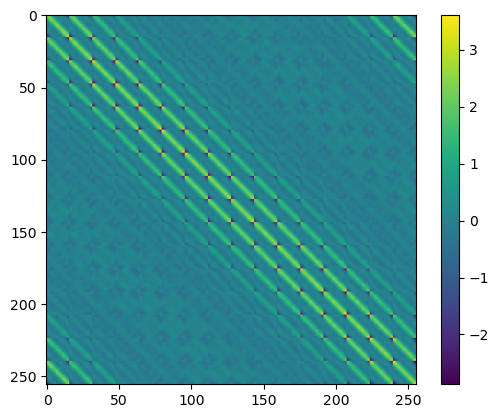

In [44]:
plt.imshow(W_ap.T@W_ap)
plt.colorbar()

In [51]:
W_ap = hamiltonian_data['AP'][0][0]
c_ap = hamiltonian_data['AP'][0][1]
b_ap = hamiltonian_data['AP'][0][2]

W_pa = hamiltonian_data['PA'][0][0]
c_pa = hamiltonian_data['PA'][0][1]
b_pa = hamiltonian_data['PA'][0][2]
    
# Run the overlap calculation
overlap_val = compute_rbm_overlap(W_ap, b_ap, c_ap, W_pa, b_pa, c_pa, n_samples=2000, n_steps=1000)
print(f"\nCalculated Normalized Overlap ⟨Φ_ap|Φ_pa⟩: {overlap_val:.5f}")

Running AIS for Z_mix / Z_ap...


KeyboardInterrupt: 

In [20]:
ensW= {}
ensbH ={}
ensbV = {}

for sector, instances in hamiltonian_data.items():
    ensW[sector] = jnp.array([inst[0] for inst in instances])
    ensbV[sector] = jnp.array([inst[1] for inst in instances])
    ensbH[sector] = jnp.array([inst[2] for inst in instances])

In [ ]:

    for W, bv, bh in sector_instances:
        # Ensure data is converted to device arrays
        W_arr = jnp.array(W, dtype=jnp.float32)
        bh_arr = jnp.array(bh, dtype=jnp.float32)
        J_total += compute_weak_coupling_J(W_arr, bh_arr)
        
    J_avg = J_total / len(sector_instances)
    J_avg = (J_avg+J_avg.T)/2